# Optimizacion de Portafolio

##### Importamos las librerias necesarias

In [5]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
from scipy.optimize import minimize

## Seccion 1: Definimos los Tickers y el Intervalo de Tiempo

#### Definimos Tickers

In [6]:
tickers = ['SPY','BND','GLD','QQQ','VTI']

#### Definimos fecha final

In [7]:
end_date = datetime.now()

#### Definimos fecha Inicial hace 5 anios

In [8]:
start_date = end_date - timedelta(days=365*5)

## 2da Seccion: Descargamos los precios de cierre

#### Creamos un dataframe para guardar los precios

In [9]:
adj_close_df = pd.DataFrame()

#### Descargamos los precios decada Ticker

In [10]:
for ticker in tickers:
    data = yf.download(ticker, start=start_date, end=end_date, progress=False)
    adj_close_df[ticker] = data['Close']

#### Veamos el DataFrame

In [11]:
print(adj_close_df.head())

                   SPY        BND         GLD         QQQ         VTI
Date                                                                 
2021-07-08  402.751099  73.783089  168.649994  348.182434  208.067551
2021-07-09  407.050385  73.552681  169.210007  350.356415  210.584763
2021-07-12  408.508453  73.527092  169.000000  351.724701  211.172089
2021-07-13  407.115753  73.296684  169.220001  351.724701  209.997421
2021-07-14  407.723267  73.544167  171.039993  352.355560  209.708405


## 3ra Seccion: Calculamos los rendimientos diarios

#### Calculamos los rendimientos diarios para cada ticker y quitamos nulos

In [12]:
log_returns = np.log(adj_close_df / adj_close_df.shift(1)).dropna()

## 4ta Seccion: Calculamos la Matriz de Covarianza

In [13]:
cov_matrix = log_returns.cov() * 252
print(cov_matrix)

          SPY       BND       GLD       QQQ       VTI
SPY  0.029405  0.002082  0.004521  0.037091  0.029878
BND  0.002082  0.003643  0.003360  0.002629  0.002191
GLD  0.004521  0.003360  0.033945  0.005794  0.004755
QQQ  0.037091  0.002629  0.005794  0.051777  0.037696
VTI  0.029878  0.002191  0.004755  0.037696  0.030627


## 5ta Seccion: Rendimiento del portafolio (metricas)

#### Calculemos el riesgo del portafolio (desviacion estandar)

In [37]:
def standard_deviation(weights, cov_matrix):
    variance = weights.T @ cov_matrix @ weights
    return np.sqrt(variance)

#### Calculemos el valor esperado del protafolio (esperanza)

Vamos a asumir que el valor esperado esta basado en el valor esperado historico

In [39]:
def expected_return(weights, log_returns):
    return np.sum(log_returns.mean() * weights) * 252

#### Calculemos el Sharpe Ratio del portafolio

Sharpe Ratio = (ve_portafolio - tasa libre de riesgo) / desviacion estandar

In [38]:
def sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate=0.01):
    return(expected_return(weights, log_returns) - risk_free_rate) / standard_deviation(weights, cov_matrix)

## 6ta Seccion: Optimizar el Portafolio

#### Tomando en cuenta la tasa libre de riesgo de mexico en Junio 2026

In [40]:
tasa_libre_de_riesgo = 0.065

#### Definimos una funcion para minimizar(negativo) el sharpe ratio

usamos scipy.optimize y solo hay minimize()function. no hay forma directa de encontar el maximo

In [41]:
def neg_sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate):
    return -sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate)

#### Definamos las limitaciones del modelo

la suma de los pesos es igual a 1
y cada peso tiene que estar entre 0 y 0.4


In [42]:
constraints = {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}
bounds = [(0, 0.4) for _ in range(len(tickers))]

#### Definamos los pesos iniciales

In [43]:
initial_weights = np.array([1/len(tickers)] * len(tickers))
print(initial_weights)

[0.2 0.2 0.2 0.2 0.2]


#### Optimizamos los pesos para maximizar el Sharpe Ratio

el metodo SLSQP es una tecnica de optimizacion numerica para resolver problemas de optimizacion no lineales usando constraints

In [44]:
optimized_results = minimize(neg_sharpe_ratio, initial_weights, args=(log_returns, cov_matrix, tasa_libre_de_riesgo), method='SLSQP', bounds=bounds, constraints=constraints)
print(optimized_results)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -0.5460919486340755
           x: [ 4.000e-01  0.000e+00  4.000e-01  2.000e-01  4.125e-16]
         nit: 5
         jac: [-3.100e-01  8.982e-02 -6.909e-01 -2.671e-01 -2.374e-01]
        nfev: 30
        njev: 5
 multipliers: [-2.671e-01]


#### Obtengamos los pesos optimos

In [47]:
optimal_weights = optimized_results.x

## 7ta Seccion: Analisis del Portafolio Optimo

### Analisis Numerico del Portafolio

In [49]:
optimal_weights = optimized_results.x

print("Optimal Weights:")
for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight:.4f}")

optimal_portfolio_return = expected_return(optimal_weights, log_returns)
optimal_portfolio_volatility = standard_deviation(optimal_weights, cov_matrix)
optimal_sharpe_ratio = sharpe_ratio(optimal_weights, log_returns, cov_matrix, tasa_libre_de_riesgo)

print(f"Expected Annual Return: {optimal_portfolio_return:.4f}")
print(f"Expected Volatility: {optimal_portfolio_volatility:.4f}")
print(f"Sharpe Ratio: {optimal_sharpe_ratio:.4f}")

Optimal Weights:
SPY: 0.4000
BND: 0.0000
GLD: 0.4000
QQQ: 0.2000
VTI: 0.0000
Expected Annual Return: 0.1432
Expected Volatility: 0.1432
Sharpe Ratio: 0.5461


### Grafica del Portafolio Optimo

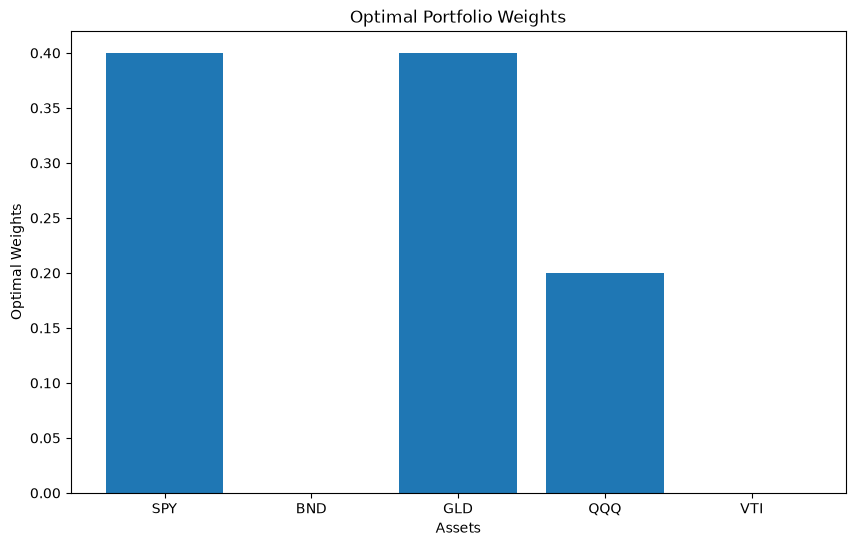

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(tickers, optimal_weights)

plt.xlabel('Assets')
plt.ylabel('Optimal Weights')
plt.title('Optimal Portfolio Weights')

plt.show()